<a href="https://colab.research.google.com/github/jami4n/Data_Analysis/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Install xgboost (not included in Colab by default)
!pip install xgboost --quiet

# --- Data libraries ---
import pandas as pd
import numpy as np

# --- Visualisation libraries ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# --- Machine Learning ---
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# --- Suppress warnings so output stays clean ---
import warnings
warnings.filterwarnings('ignore')

# Make all charts look consistent
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 12

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [25]:
# Load the Ames Housing dataset
print('Loading dataset... (this may take a few seconds)')
housing = fetch_openml(name='house_prices', as_frame=True, parser='auto')

# Combine into one dataframe
df = housing.frame.copy()

# Make sure SalePrice is numeric
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

print(f'✅ Dataset loaded!')
print(f'   Rows    : {df.shape[0]:,}')
print(f'   Columns : {df.shape[1]:,}')
print()

# Preview the first 5 rows
df.head()

Loading dataset... (this may take a few seconds)
✅ Dataset loaded!
   Rows    : 1,460
   Columns : 81



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


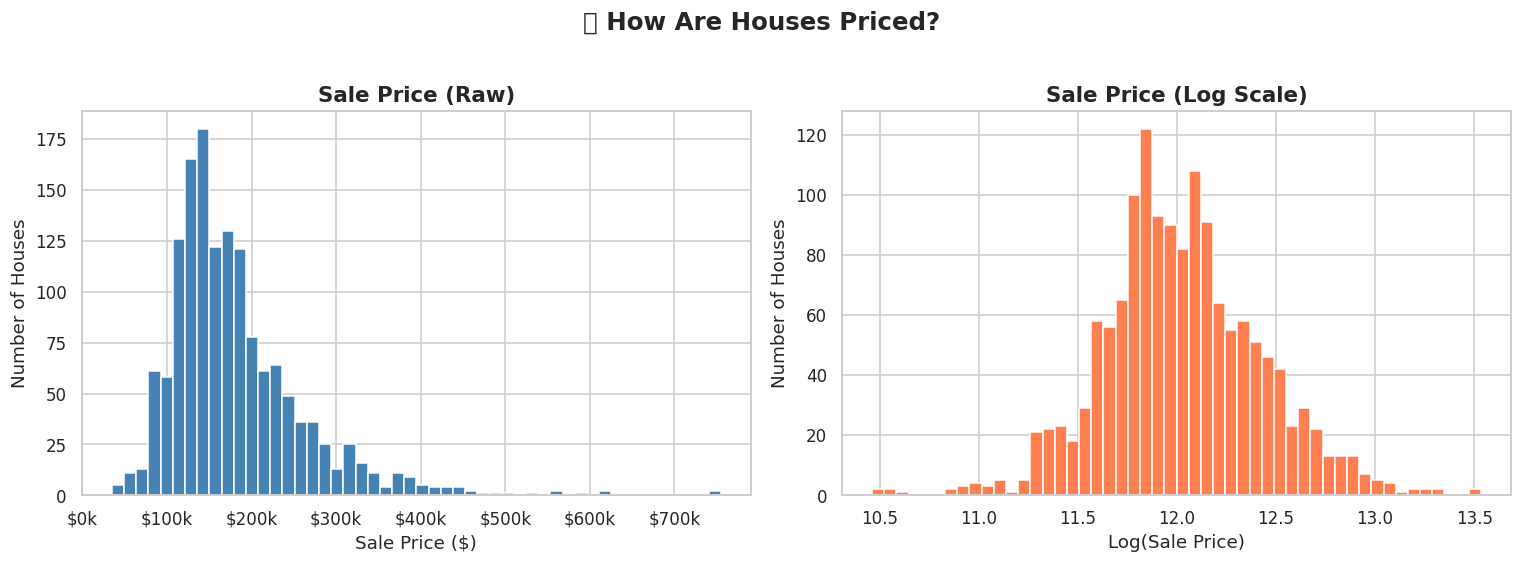

Average price : $180,921
Median price  : $163,000
Cheapest house: $34,900
Priciest house: $755,000


In [26]:
# --- Price Distribution: Raw vs Log Scale ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw price
axes[0].hist(df['SalePrice'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sale Price (Raw)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Number of Houses')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Right: log-transformed price
axes[1].hist(np.log1p(df['SalePrice'].dropna()), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Sale Price (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Number of Houses')

plt.suptitle('📈 How Are Houses Priced?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Average price : ${df['SalePrice'].mean():,.0f}")
print(f"Median price  : ${df['SalePrice'].median():,.0f}")
print(f"Cheapest house: ${df['SalePrice'].min():,.0f}")
print(f"Priciest house: ${df['SalePrice'].max():,.0f}")

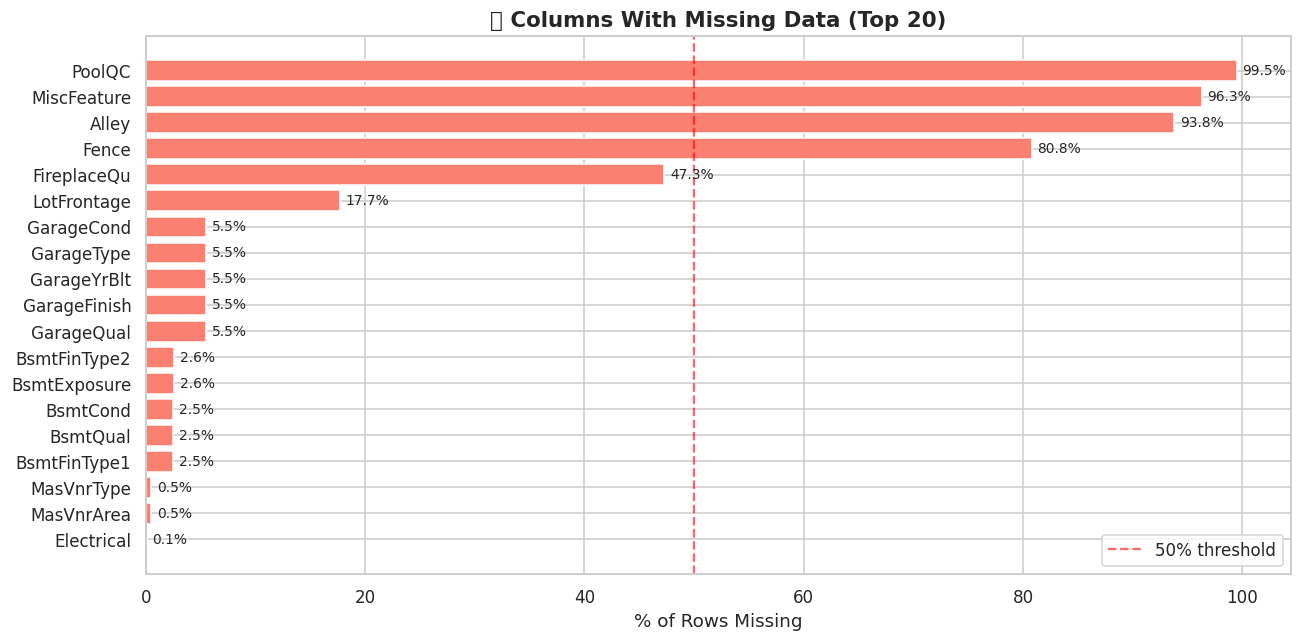

Total columns with missing data: 19

Columns past the 50% line will be dropped in the cleaning step.


In [27]:
# --- Missing Data Chart ---
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(20)
missing_pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(missing.index[::-1], missing_pct.values[::-1], color='salmon', edgecolor='white')

ax.set_xlabel('% of Rows Missing')
ax.set_title('🔍 Columns With Missing Data (Top 20)', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6, label='50% threshold')
ax.legend()

# Add percentage labels on each bar
for bar, pct in zip(bars, missing_pct.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Total columns with missing data: {len(missing)}')
print()
print('Columns past the 50% line will be dropped in the cleaning step.')

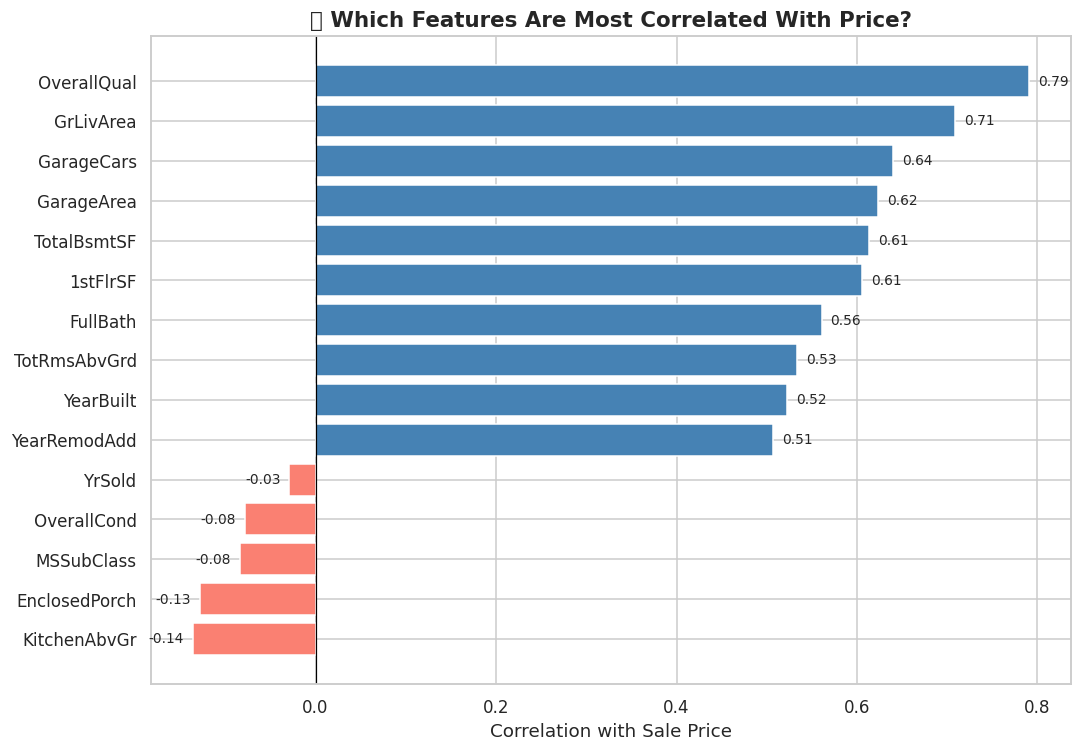

Blue  = positively correlated (more of this → higher price)
Red   = negatively correlated (more of this → lower price)

Top 5 features most correlated with price:
   OverallQual          0.791
   GrLivArea            0.709
   GarageCars           0.640
   GarageArea           0.623
   TotalBsmtSF          0.614


In [28]:
# --- Correlation With Sale Price ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_price = df[numeric_cols].corr()['SalePrice'].drop('SalePrice').sort_values()

# Take top 10 positive and top 5 negative
top_pos = corr_with_price.tail(10)
top_neg = corr_with_price.head(5)
combined = pd.concat([top_neg, top_pos])

colors = ['salmon' if v < 0 else 'steelblue' for v in combined.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(combined.index, combined.values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Sale Price')
ax.set_title('🔗 Which Features Are Most Correlated With Price?', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, combined.values):
    xpos = bar.get_width() + (0.01 if val >= 0 else -0.01)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('Blue  = positively correlated (more of this → higher price)')
print('Red   = negatively correlated (more of this → lower price)')
print()
print('Top 5 features most correlated with price:')
for feat, val in corr_with_price.tail(5)[::-1].items():
    print(f'   {feat:<20} {val:.3f}')

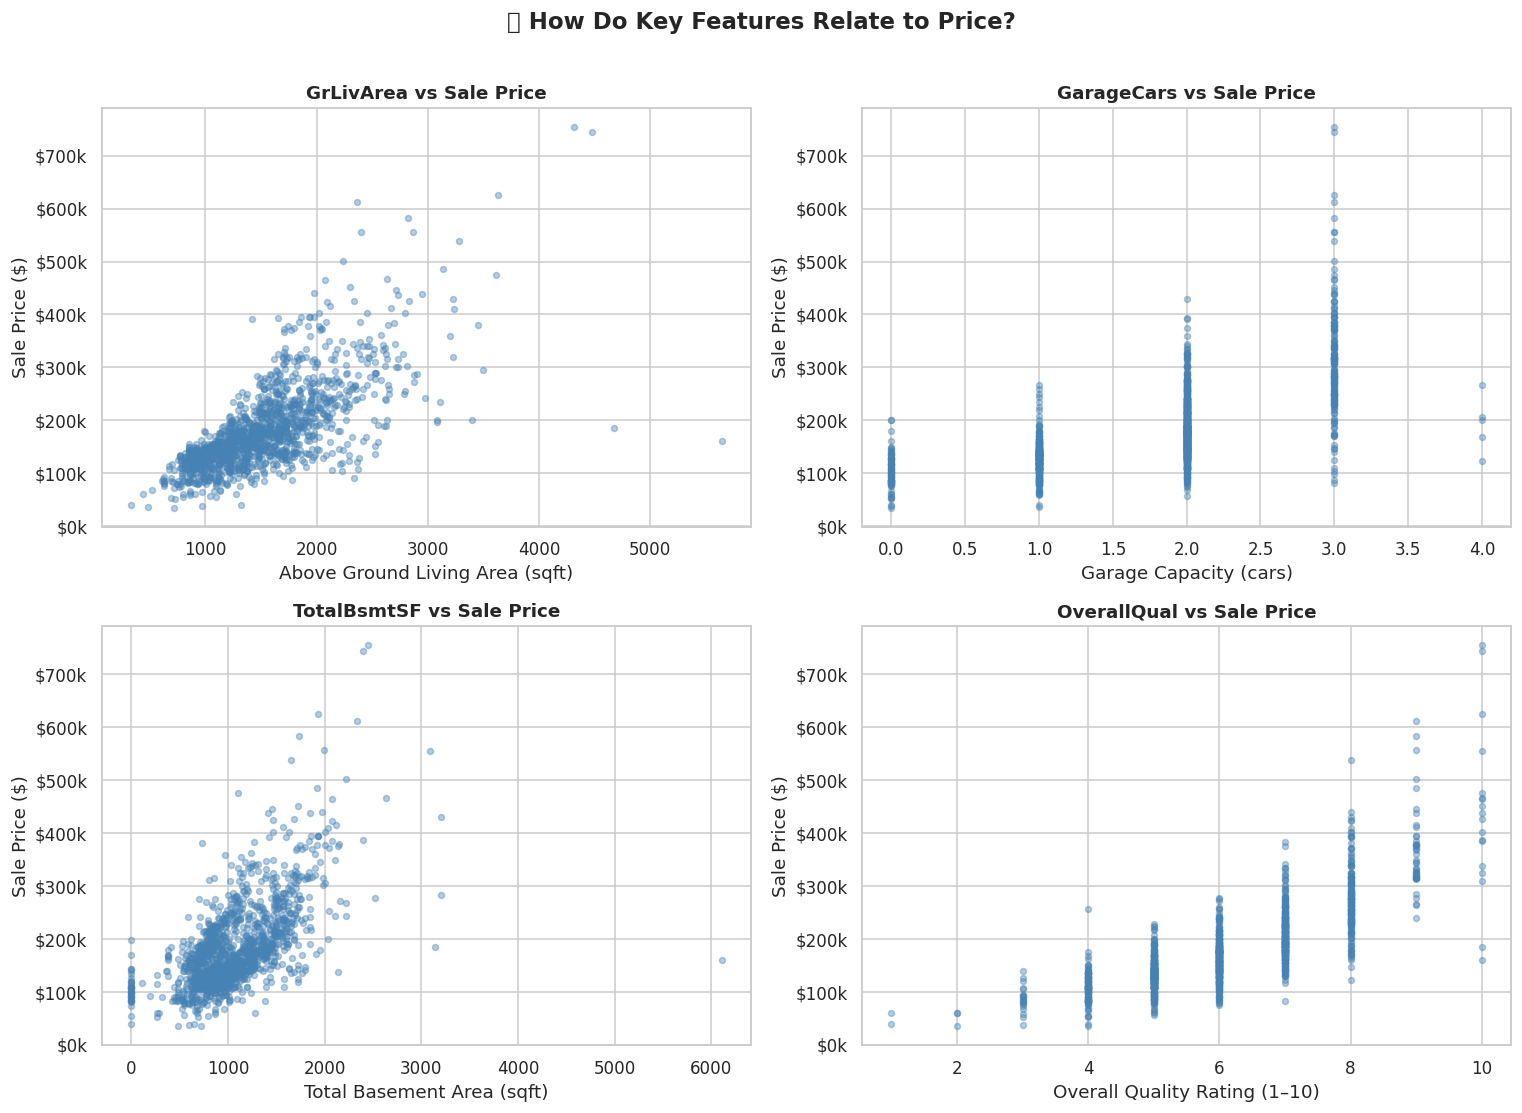

In [29]:
# --- Scatter Plots: Key Features vs Price ---
top_features = ['GrLivArea', 'GarageCars', 'TotalBsmtSF', 'OverallQual']
labels = [
    'Above Ground Living Area (sqft)',
    'Garage Capacity (cars)',
    'Total Basement Area (sqft)',
    'Overall Quality Rating (1–10)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(top_features, labels)):
    x = pd.to_numeric(df[feat], errors='coerce')
    y = df['SalePrice']
    mask = x.notna() & y.notna()

    axes[i].scatter(x[mask], y[mask], alpha=0.4, color='steelblue', s=15)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Sale Price ($)')
    axes[i].set_title(f'{feat} vs Sale Price', fontweight='bold')
    axes[i].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

plt.suptitle('📊 How Do Key Features Relate to Price?', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

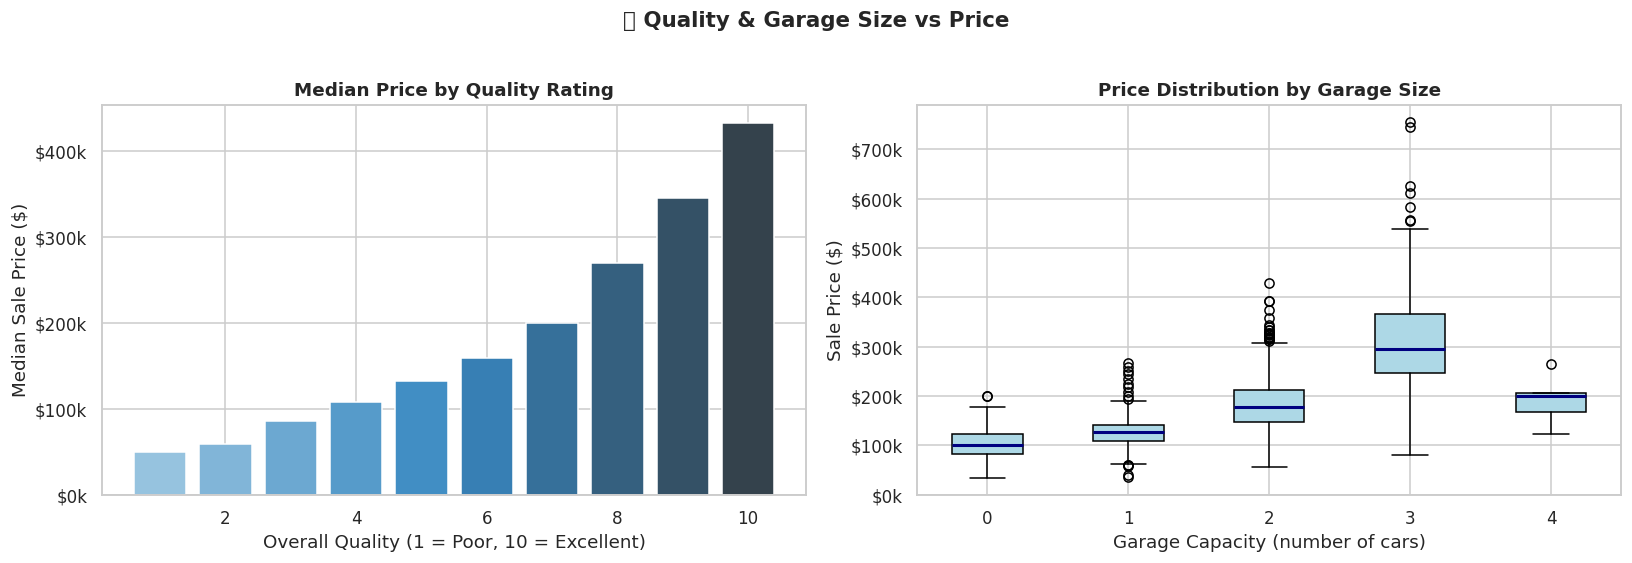

In [30]:
# --- Price by Quality Rating & Garage Size ---
df['OverallQual'] = pd.to_numeric(df['OverallQual'], errors='coerce')
df['GarageCars']  = pd.to_numeric(df['GarageCars'],  errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: median price per quality rating
qual_price = df.groupby('OverallQual')['SalePrice'].median().reset_index()
axes[0].bar(qual_price['OverallQual'], qual_price['SalePrice'],
            color=sns.color_palette('Blues_d', len(qual_price)), edgecolor='white')
axes[0].set_xlabel('Overall Quality (1 = Poor, 10 = Excellent)')
axes[0].set_ylabel('Median Sale Price ($)')
axes[0].set_title('Median Price by Quality Rating', fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

# Right: price distribution per garage size
df_g = df[df['GarageCars'].isin([0, 1, 2, 3, 4])]
groups = [df_g[df_g['GarageCars'] == g]['SalePrice'].dropna().values for g in [0, 1, 2, 3, 4]]
axes[1].boxplot(groups, labels=['0', '1', '2', '3', '4'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_xlabel('Garage Capacity (number of cars)')
axes[1].set_ylabel('Sale Price ($)')
axes[1].set_title('Price Distribution by Garage Size', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

plt.suptitle('🔎 Quality & Garage Size vs Price', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# --- 4a. Drop columns with >50% missing values ---
thresh = len(df) * 0.5
df_clean = df.dropna(axis=1, thresh=thresh).copy()

print(f'Columns before : {df.shape[1]}')
print(f'Columns after  : {df_clean.shape[1]}')
print(f'Columns dropped: {df.shape[1] - df_clean.shape[1]}')
print()

# --- 4b. Drop rows where SalePrice is missing ---
df_clean = df_clean.dropna(subset=['SalePrice'])
print(f'Rows remaining : {len(df_clean):,}')
print()

# --- 4c. Fill remaining missing values ---
# Numeric columns → fill with the median (middle value)
num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Categorical columns → fill with 'Unknown'
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('Unknown')

print(f'Missing values remaining: {df_clean.isnull().sum().sum()}')
print()

# --- 4d. Encode text columns as numbers ---
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print(f'✅ Data cleaned and encoded!')
print(f'   Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

Columns before : 81
Columns after  : 77
Columns dropped: 4

Rows remaining : 1,460

Missing values remaining: 0

✅ Data cleaned and encoded!
   Final shape: 1,460 rows × 77 columns


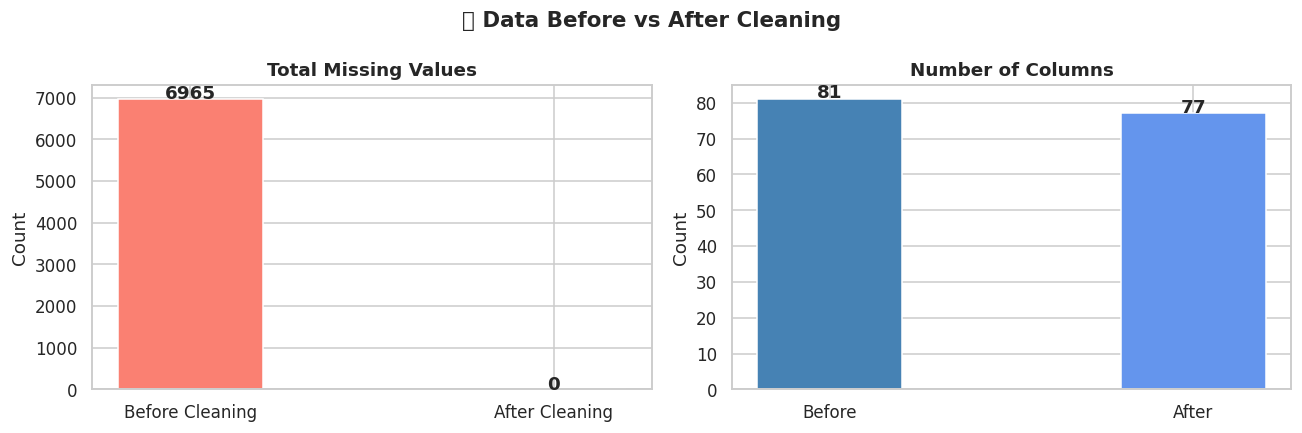

✅ Zero missing values — the data is ready for feature engineering!


In [32]:
# --- Before vs After Cleaning ---
before_missing = df.isnull().sum().sum()
after_missing  = df_clean.isnull().sum().sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: missing values before vs after
axes[0].bar(['Before Cleaning', 'After Cleaning'],
            [before_missing, after_missing],
            color=['salmon', 'mediumseagreen'], edgecolor='white', width=0.4)
axes[0].set_title('Total Missing Values', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([before_missing, after_missing]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Right: number of columns before vs after
axes[1].bar(['Before', 'After'],
            [df.shape[1], df_clean.shape[1]],
            color=['steelblue', 'cornflowerblue'], edgecolor='white', width=0.4)
axes[1].set_title('Number of Columns', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([df.shape[1], df_clean.shape[1]]):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.suptitle('🧹 Data Before vs After Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✅ Zero missing values — the data is ready for feature engineering!')

In [33]:
# --- Make sure key columns are numeric ---
for col in ['TotalBsmtSF', 'GrLivArea', 'YrSold', 'YearBuilt', 'YearRemodAdd',
            'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'PoolArea']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

# --- Create new features ---

# Total square footage: basement + above ground living area
df_clean['TotalSF'] = df_clean['TotalBsmtSF'] + df_clean['GrLivArea']

# How old the house was when it was sold
df_clean['HouseAge'] = df_clean['YrSold'] - df_clean['YearBuilt']

# How long since the last remodel
df_clean['RemodAge'] = df_clean['YrSold'] - df_clean['YearRemodAdd']

# Total bathrooms (half baths count as 0.5)
df_clean['TotalBath'] = (df_clean['FullBath'] +
                         df_clean['BsmtFullBath'] +
                         0.5 * df_clean['HalfBath'] +
                         0.5 * df_clean['BsmtHalfBath'])

# Simple yes/no flag for having a pool
df_clean['HasPool'] = (df_clean['PoolArea'] > 0).astype(int)

print('✅ New features created:')
new_feats = ['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'HasPool']
print(df_clean[new_feats].describe().round(1))

✅ New features created:
       TotalSF  HouseAge  RemodAge  TotalBath  HasPool
count   1460.0    1460.0    1460.0     1460.0   1460.0
mean    2572.9      36.5      23.0        2.2      0.0
std      823.6      30.3      20.6        0.8      0.1
min      334.0       0.0      -1.0        1.0      0.0
25%     2014.0       8.0       4.0        2.0      0.0
50%     2479.0      35.0      14.0        2.0      0.0
75%     3008.5      54.0      41.0        2.5      0.0
max    11752.0     136.0      60.0        6.0      1.0


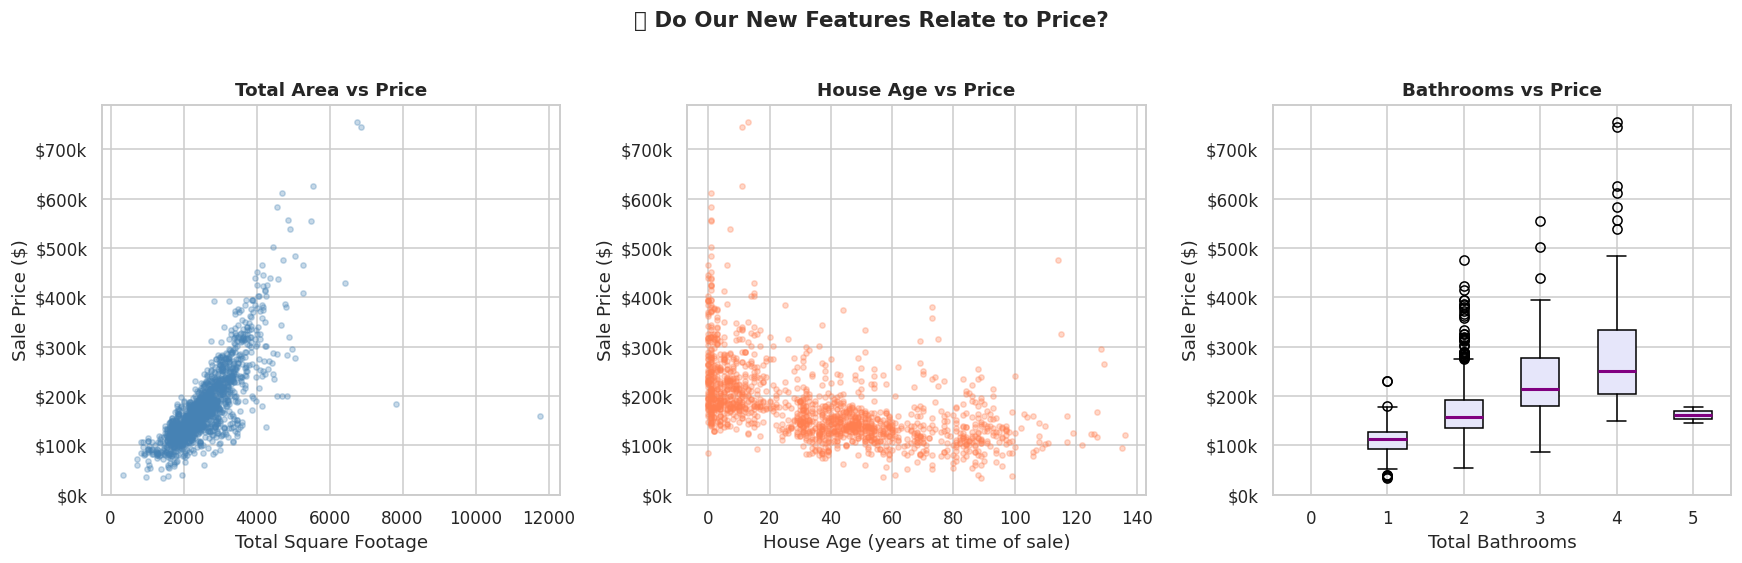

TotalSF correlation with price  : 0.779
HouseAge correlation with price : -0.523
TotalBath correlation with price: 0.632


In [34]:
# --- Do our new features relate to price? ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# TotalSF vs Price
axes[0].scatter(df_clean['TotalSF'], df_clean['SalePrice'],
                alpha=0.3, color='steelblue', s=12)
axes[0].set_xlabel('Total Square Footage')
axes[0].set_ylabel('Sale Price ($)')
axes[0].set_title('Total Area vs Price', fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

# HouseAge vs Price
axes[1].scatter(df_clean['HouseAge'], df_clean['SalePrice'],
                alpha=0.3, color='coral', s=12)
axes[1].set_xlabel('House Age (years at time of sale)')
axes[1].set_ylabel('Sale Price ($)')
axes[1].set_title('House Age vs Price', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

# TotalBath vs Price (as a box plot per bathroom count)
df_clean['BathBucket'] = df_clean['TotalBath'].round(0).astype(int).clip(0, 5)
groups = [df_clean[df_clean['BathBucket'] == b]['SalePrice'].dropna().values
          for b in range(0, 6)]
axes[2].boxplot(groups, labels=[str(i) for i in range(0, 6)], patch_artist=True,
                boxprops=dict(facecolor='lavender'),
                medianprops=dict(color='purple', linewidth=2))
axes[2].set_xlabel('Total Bathrooms')
axes[2].set_ylabel('Sale Price ($)')
axes[2].set_title('Bathrooms vs Price', fontweight='bold')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

plt.suptitle('🛠️ Do Our New Features Relate to Price?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('TotalSF correlation with price  :', round(df_clean['TotalSF'].corr(df_clean['SalePrice']), 3))
print('HouseAge correlation with price :', round(df_clean['HouseAge'].corr(df_clean['SalePrice']), 3))
print('TotalBath correlation with price:', round(df_clean['TotalBath'].corr(df_clean['SalePrice']), 3))

Features used  : 81
Training houses: 1,168
Test houses    : 292



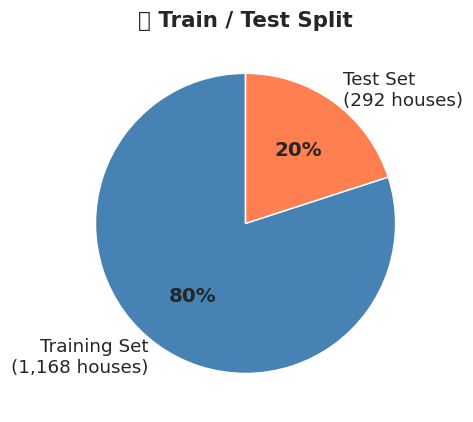

💡 The model trains on the blue slice, then gets tested on the red slice.


In [35]:
# --- Prepare features (X) and target (y) ---
target = 'SalePrice'
X = df_clean.drop(columns=[target, 'BathBucket'], errors='ignore')
y = np.log1p(df_clean[target])  # log-transform price for better model performance

# Make sure everything is numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# --- Split: 80% for training, 20% for testing ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Features used  : {X_train.shape[1]}')
print(f'Training houses: {X_train.shape[0]:,}')
print(f'Test houses    : {X_test.shape[0]:,}')
print()

# Visualise the split
fig, ax = plt.subplots(figsize=(7, 4))
sizes = [X_train.shape[0], X_test.shape[0]]
labels = [f'Training Set\n({X_train.shape[0]:,} houses)',
          f'Test Set\n({X_test.shape[0]:,} houses)']
wedges, texts, autotexts = ax.pie(sizes, labels=labels,
                                   colors=['steelblue', 'coral'],
                                   autopct='%1.0f%%', startangle=90,
                                   textprops={'fontsize': 12})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)

ax.set_title('🔀 Train / Test Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 The model trains on the blue slice, then gets tested on the red slice.')


In [36]:
# --- Train all four models and evaluate ---
from sklearn.linear_model import LinearRegression

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=10),
    'Random Forest'    : RandomForestRegressor(n_estimators=200, max_depth=15,
                                                random_state=42, n_jobs=-1),
    'XGBoost'          : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                       max_depth=6, random_state=42,
                                       verbosity=0, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Convert log predictions back to real dollar amounts
    preds_real  = np.expm1(preds)
    y_test_real = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
    r2   = r2_score(y_test_real, preds_real)

    results[name] = {'model': model, 'preds': preds_real, 'RMSE': rmse, 'R2': r2}

    print(f'   ✅ Done!  RMSE: ${rmse:,.0f}   |   R²: {r2:.3f}')
    print()

print('=' * 50)
print('All models trained!')
print()
print('📌 What do these numbers mean?')
print('   RMSE = average dollar error in predictions (lower is better)')
print('   R²   = % of price variation explained (closer to 1.0 is better)')

Training Linear Regression...
   ✅ Done!  RMSE: $26,121   |   R²: 0.911

Training Ridge Regression...
   ✅ Done!  RMSE: $27,651   |   R²: 0.900

Training Random Forest...
   ✅ Done!  RMSE: $30,165   |   R²: 0.881

Training XGBoost...
   ✅ Done!  RMSE: $26,493   |   R²: 0.908

All models trained!

📌 What do these numbers mean?
   RMSE = average dollar error in predictions (lower is better)
   R²   = % of price variation explained (closer to 1.0 is better)


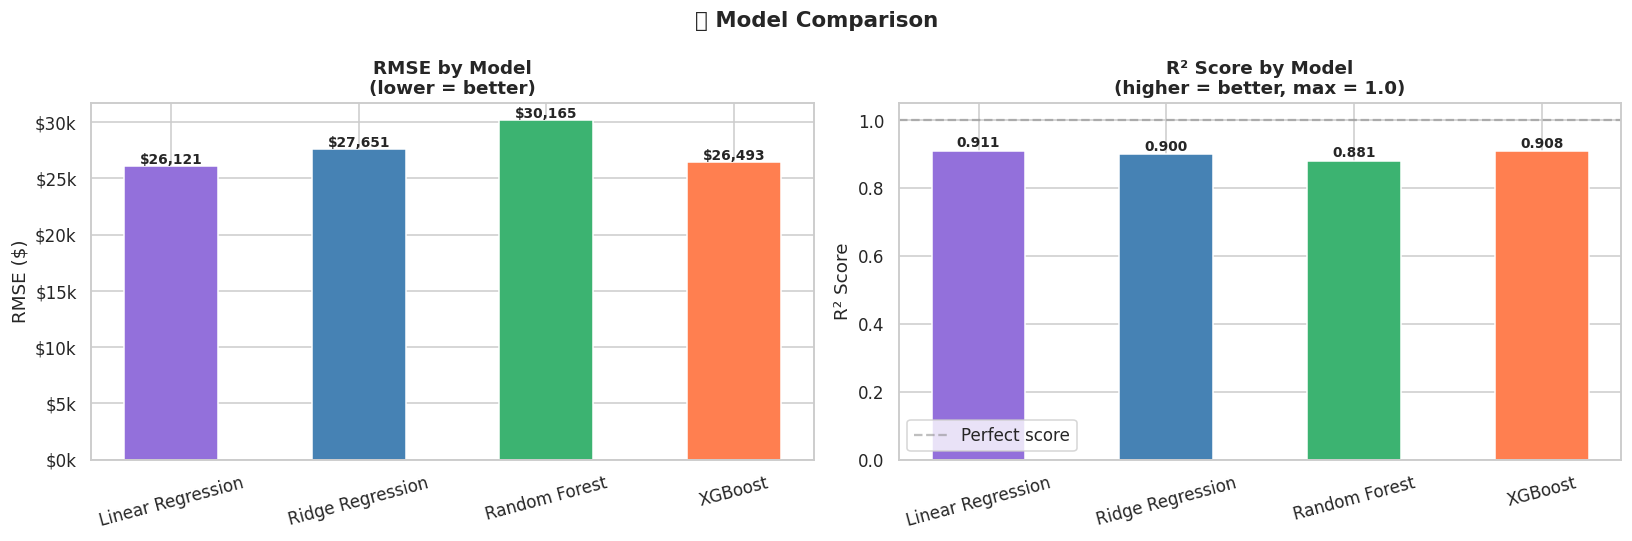


Model                          RMSE       R²
--------------------------------------------
Linear Regression      $    26,121    0.911
Ridge Regression       $    27,651    0.900
Random Forest          $    30,165    0.881
XGBoost                $    26,493    0.908


In [37]:
# --- Compare RMSE and R² across all four models ---
model_names = list(results.keys())
rmse_vals   = [results[m]['RMSE'] for m in model_names]
r2_vals     = [results[m]['R2']   for m in model_names]
colors_bar  = ['mediumpurple', 'steelblue', 'mediumseagreen', 'coral']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: RMSE bars
bars1 = axes[0].bar(model_names, rmse_vals, color=colors_bar, edgecolor='white', width=0.5)
axes[0].set_title('RMSE by Model\n(lower = better)', fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Right: R² bars
bars2 = axes[1].bar(model_names, r2_vals, color=colors_bar, edgecolor='white', width=0.5)
axes[1].set_title('R² Score by Model\n(higher = better, max = 1.0)', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=1.0, color='grey', linestyle='--', alpha=0.5, label='Perfect score')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('🏆 Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print a clean summary table
print(f'\n{"Model":<22} {"RMSE":>12} {"R²":>8}')
print('-' * 44)
for name in model_names:
    r = results[name]
    print(f'{name:<22} ${r["RMSE"]:>10,.0f} {r["R2"]:>8.3f}')


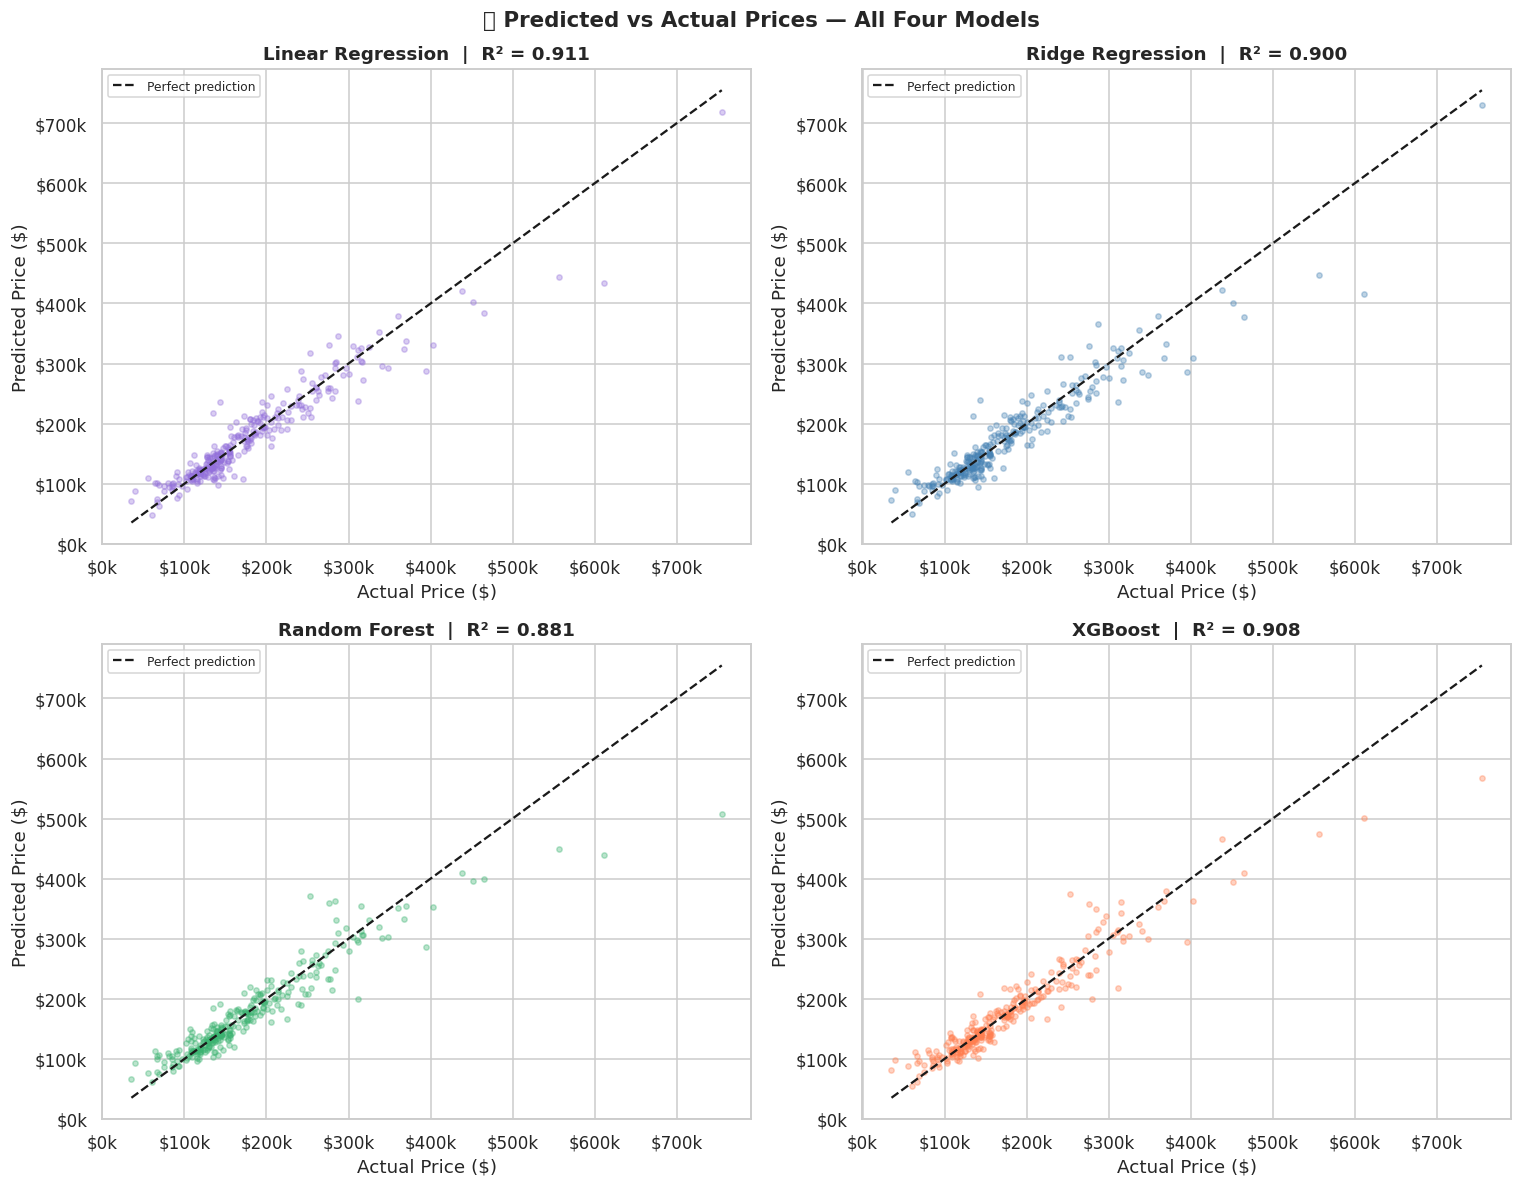

💡 Dots sitting on the dashed line = perfect prediction.
   Dots above the line = model over-predicted (thought it was worth more).
   Dots below the line = model under-predicted (thought it was worth less).


In [38]:
# --- Predicted vs Actual Prices ---
y_test_real = np.expm1(y_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (name, color) in enumerate(zip(model_names, colors_bar)):
    preds = results[name]['preds']

    axes[i].scatter(y_test_real, preds, alpha=0.35, s=12, color=color)

    # Perfect prediction line
    mn = min(y_test_real.min(), preds.min())
    mx = max(y_test_real.max(), preds.max())
    axes[i].plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect prediction')

    axes[i].set_xlabel('Actual Price ($)')
    axes[i].set_ylabel('Predicted Price ($)')
    axes[i].set_title(f'{name}  |  R² = {results[name]["R2"]:.3f}', fontweight='bold')
    axes[i].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))
    axes[i].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))
    axes[i].legend(fontsize=8)

plt.suptitle('🎯 Predicted vs Actual Prices — All Four Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Dots sitting on the dashed line = perfect prediction.')
print('   Dots above the line = model over-predicted (thought it was worth more).')
print('   Dots below the line = model under-predicted (thought it was worth less).')

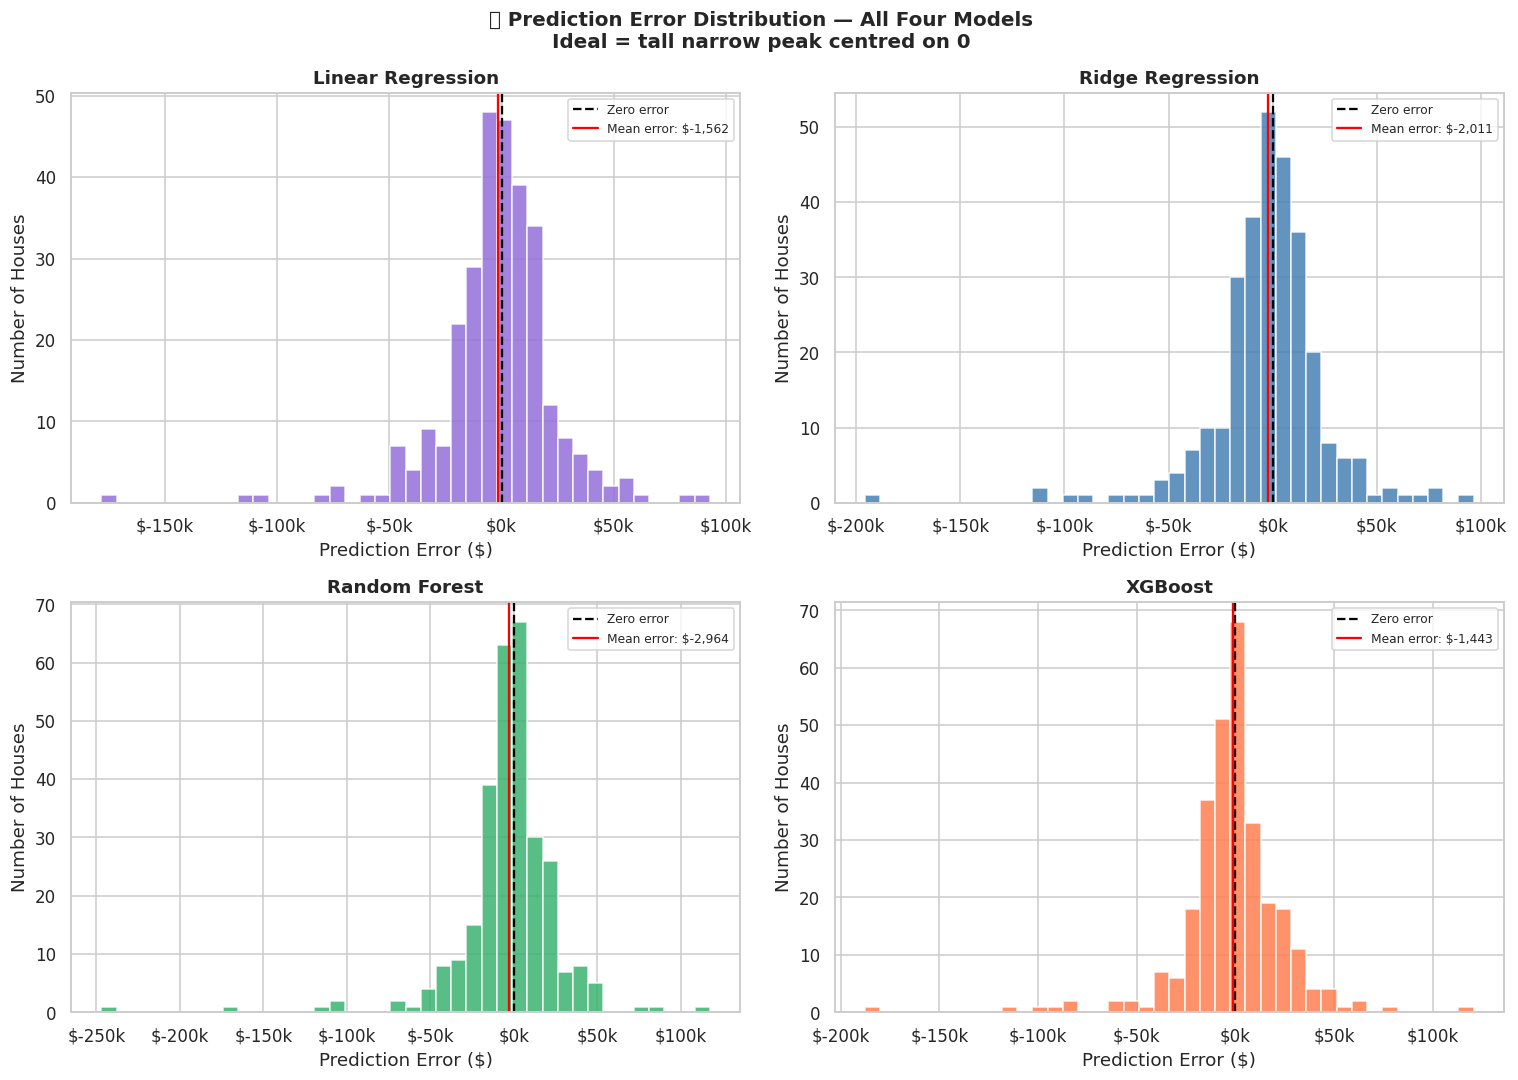

💡 What to look for:
   Narrow peak  = most predictions are close to correct
   Centred on 0 = model is not systematically over or under predicting
   Long tails   = occasional large errors on unusual houses


In [39]:
# --- Error Distribution for All Four Models ---
y_test_real = np.expm1(y_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, color) in enumerate(zip(model_names, colors_bar)):
    errors = results[name]['preds'] - y_test_real.values

    axes[i].hist(errors, bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(x=0, color='black', linewidth=1.5, linestyle='--', label='Zero error')

    # Add mean error line
    mean_err = errors.mean()
    axes[i].axvline(x=mean_err, color='red', linewidth=1.5,
                    linestyle='-', label=f'Mean error: ${mean_err:+,.0f}')

    axes[i].set_xlabel('Prediction Error ($)')
    axes[i].set_ylabel('Number of Houses')
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))
    axes[i].legend(fontsize=8)

plt.suptitle('📉 Prediction Error Distribution — All Four Models\n'
             'Ideal = tall narrow peak centred on 0',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 What to look for:')
print('   Narrow peak  = most predictions are close to correct')
print('   Centred on 0 = model is not systematically over or under predicting')
print('   Long tails   = occasional large errors on unusual houses')

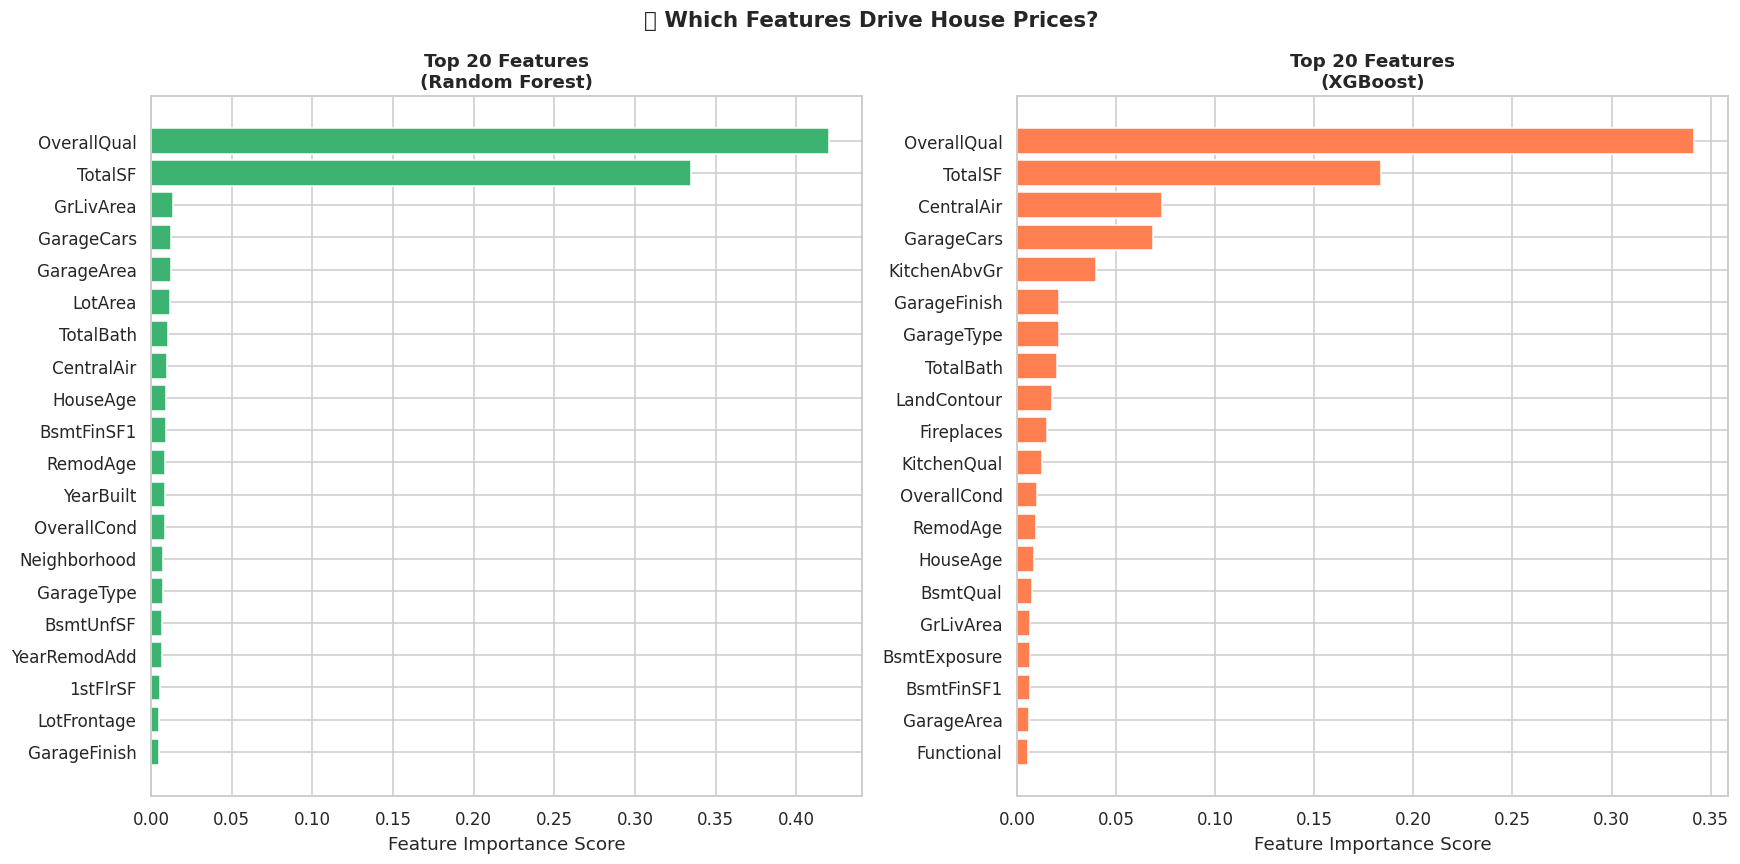

In [40]:
# --- Feature Importance: Random Forest vs XGBoost ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, model_name, color in zip(axes,
                                  ['Random Forest', 'XGBoost'],
                                  ['mediumseagreen', 'coral']):
    model       = results[model_name]['model']
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top20       = importances.sort_values(ascending=True).tail(20)

    ax.barh(top20.index, top20.values, color=color, edgecolor='white')
    ax.set_xlabel('Feature Importance Score')
    ax.set_title(f'Top 20 Features\n({model_name})', fontweight='bold')

plt.suptitle('🔑 Which Features Drive House Prices?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# --- Final Project Summary ---
print('=' * 55)
print('           📋 PROJECT SUMMARY')
print('=' * 55)
print()
print(f'Dataset  : Ames Housing ({len(df_clean):,} houses, {X.shape[1]} features)')
print(f'New features engineered: TotalSF, HouseAge, RemodAge,')
print(f'                         TotalBath, HasPool')
print()
print(f'{"Model":<22} {"RMSE":>12} {"R²":>8}')
print('-' * 44)
for name in model_names:
    r = results[name]
    print(f'{name:<22} ${r["RMSE"]:>10,.0f} {r["R2"]:>8.3f}')
print()

best = min(results.items(), key=lambda x: x[1]['RMSE'])
print(f'🏆 Best model : {best[0]}')
print(f'   Average prediction error : ${best[1]["RMSE"]:,.0f}')
print(f'   Price variation explained: {best[1]["R2"]*100:.1f}%')
print()

# Top 5 features from Random Forest
print('🔑 Top 5 price drivers (Random Forest):')
rf_imp = pd.Series(results['Random Forest']['model'].feature_importances_,
                   index=X_train.columns).sort_values(ascending=False)
for feat, imp in rf_imp.head(5).items():
    print(f'   • {feat:<20} importance: {imp:.3f}')

print()

           📋 PROJECT SUMMARY

Dataset  : Ames Housing (1,460 houses, 81 features)
New features engineered: TotalSF, HouseAge, RemodAge,
                         TotalBath, HasPool

Model                          RMSE       R²
--------------------------------------------
Linear Regression      $    26,121    0.911
Ridge Regression       $    27,651    0.900
Random Forest          $    30,165    0.881
XGBoost                $    26,493    0.908

🏆 Best model : Linear Regression
   Average prediction error : $26,121
   Price variation explained: 91.1%

🔑 Top 5 price drivers (Random Forest):
   • OverallQual          importance: 0.420
   • TotalSF              importance: 0.335
   • GrLivArea            importance: 0.013
   • GarageCars           importance: 0.013
   • GarageArea           importance: 0.013

